In [1]:
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
# torch.multiprocessing.set_start_method('spawn', force=True)
import time
import importlib
import torch.optim as optim
from torchsummary import summary
import os
import statistics

os.chdir("../")
from src.data_preparation import SimulatedDataset, collate_function, load_real_data
from src.transformers import MiniTransformer
import src.transformers as transformerFunctions
from src.transformers import init_weights_recursive
from src.transformers import print_parameters
from src.transformers import create_custom_mask_pair,create_custom_mask_pred, create_distance_to_end_matrix, create_pairwise_distance_matrix
from src.evaluation import calculate_bench1_loss, calculate_bench2_loss, calculate_repeat_loss, calculate_regression_loss, evaluate_mini_transformer
from src.statistical_testing import statistical_testing, print_p_values, plot_context_predindex_pair_effect, get_context_predindex_pair_effect, get_the_existing_comb
import torch.autograd.profiler as profiler
from sklearn.model_selection import KFold
device = torch.device("cpu")

In [2]:

if __name__ == '__main__':

    # Hyperparameters
    # data_str = "ghq_b_sum"
    # data_str = "ghq_sum"
    data_str = "simulation"
    batch_size = 1           # Batch size for loading data
    dk = 1                  # d_k
    dv = 1                  # d_v
    nheads = 4             # number of heads
    ncum = 4                 # number of cumulants
    maxlen = 10             # maximum length of the sequence
    learning_rate = 1e-3
    lambda_l2 = 1e-3
    EPOCHS = 200
    target_sample_size = 16
    nrepp = 1
    
    # Set the random seed for reproducibility
    seed = 12345
    torch.manual_seed(seed)
    
    n = 50
    p = 4
    maxlen = 10
    # Create Dataset and DataLoader
    train_dataset = SimulatedDataset(n, p, maxlen=maxlen, device = device).data
    # eval_dataset = SimulatedDataset(1000, p, maxlen=maxlen, device = device).data
    predindex = 2
    


    n = len(train_dataset)
    p = train_dataset[0].shape[1]
    print("Sample size: ", len(train_dataset), "\n")
    



    mask_pairwise = create_custom_mask_pair(maxlen, device)
    distance_to_end_matrix = create_distance_to_end_matrix(maxlen, device)
    pairwise_distance_matrix = create_pairwise_distance_matrix(maxlen, device)


    dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_function,  num_workers=0)
    # eval_dataloader = DataLoader(eval_dataset, batch_size=1000, shuffle=False, collate_fn=collate_function, num_workers=0)

    model = MiniTransformer(p, nheads, dk, dv, ncum, mask_pairwise, pairwise_distance_matrix, distance_to_end_matrix,  device)

    # model.apply(init_weights_recursive)
    model.to(device)

    # model = torch.compile(model)
    # Start the timer
    start_time = time.time()

    # Define optimizer
    # optimizer = optim.Adam(model.parameters(), lr= learning_rate, weight_decay=lambda_l2)
    optimizer = optim.Adam(model.parameters(), lr= learning_rate)
    
    print("Number of Parameters", transformerFunctions.count_parameters(model))
    
    run_path = transformerFunctions.train_mini_transformer(model, dataloader, None, optimizer, lambda_l2, EPOCHS, device)


    # End the timer
    end_time = time.time()

    # Calculate and print the execution time
    execution_time = end_time - start_time 
    print(f"Execution time: {execution_time:.6f} seconds")




Sample size:  50 

Number of Parameters 98
EPOCH 1:
avg_loss:     7.80849 penalty    : 0.00659
EPOCH 11:
avg_loss:     3.50976 penalty    : 0.00861
EPOCH 21:
avg_loss:     3.36811 penalty    : 0.01051
EPOCH 31:
avg_loss:     3.25567 penalty    : 0.01300
EPOCH 41:
avg_loss:     3.21032 penalty    : 0.01441
EPOCH 51:
avg_loss:     3.18694 penalty    : 0.01549
EPOCH 61:
avg_loss:     3.16502 penalty    : 0.01661
EPOCH 71:
avg_loss:     3.14536 penalty    : 0.01768
EPOCH 81:
avg_loss:     3.13198 penalty    : 0.01893
EPOCH 91:
avg_loss:     3.11284 penalty    : 0.02024
EPOCH 101:
avg_loss:     3.09195 penalty    : 0.02188
EPOCH 111:
avg_loss:     3.06881 penalty    : 0.02369
EPOCH 121:
avg_loss:     3.04879 penalty    : 0.02562
EPOCH 131:
avg_loss:     3.02949 penalty    : 0.02720
EPOCH 141:
avg_loss:     3.01729 penalty    : 0.02844
EPOCH 151:
avg_loss:     3.00311 penalty    : 0.02941
EPOCH 161:
avg_loss:     2.99437 penalty    : 0.03019
EPOCH 171:
avg_loss:     2.99378 penalty    : 0.03

In [3]:
avepval, stdpval, context, targetall = statistical_testing(model, train_dataset, p, predindex, nrepp, target_sample_size)

Repetition 1/1
Processed 10000000 combinations out of approximately 4294967296
Processed 20000000 combinations out of approximately 4294967296
Processed 30000000 combinations out of approximately 4294967296
Processed 40000000 combinations out of approximately 4294967296
Processed 50000000 combinations out of approximately 4294967296
Processed 60000000 combinations out of approximately 4294967296
Processed 70000000 combinations out of approximately 4294967296
Processed 80000000 combinations out of approximately 4294967296
Processed 90000000 combinations out of approximately 4294967296
Processed 100000000 combinations out of approximately 4294967296
Processed 110000000 combinations out of approximately 4294967296
Processed 120000000 combinations out of approximately 4294967296
Processed 130000000 combinations out of approximately 4294967296
Processed 140000000 combinations out of approximately 4294967296
Processed 150000000 combinations out of approximately 4294967296
Processed 160000000

In [4]:
print_p_values(avepval, stdpval)

Variable 1: 0.0007 ± 0.00
Variable 2: 0.0022 ± 0.00
Variable 3: 0.0071 ± 0.00
Variable 4: 0.6352 ± 0.00


In [5]:
context_predindex_pair_effect = get_context_predindex_pair_effect(model, p, context, targetall)    

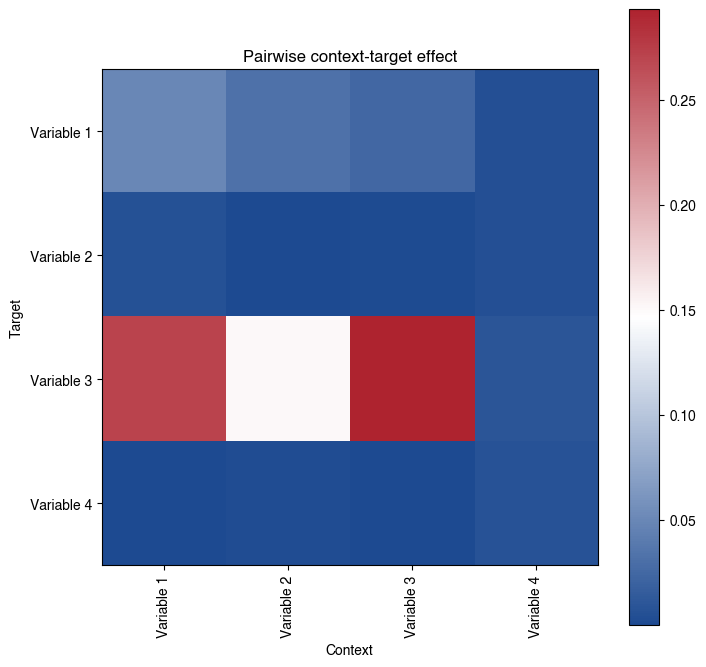

<module 'matplotlib.pyplot' from '/Users/farhadyar/Desktop/mini_transformer/env/lib/python3.10/site-packages/matplotlib/pyplot.py'>

In [6]:
plot_context_predindex_pair_effect(context_predindex_pair_effect, f"exact_{data_str}", "./notebooks/statistical_testing/approx.->exact")

In [7]:
with open(f"./notebooks/statistical_testing/statistical_testing_{data_str}_results_n={n}_batch_size={batch_size}_p={p}_ncum={ncum}_nheads={nheads}_epochs={EPOCHS}_seed={seed}.txt", "a") as f:
    f.write("For combination sample size: all (exact) \n")
    for i in range(avepval.shape[0]):
        f.write(f"Variable {i+1}: {avepval[i]:.4f} ± {stdpval[i]:.2f}\n")

    